In [37]:
# import dependencies for Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [38]:
# import dataset

F18 = pd.read_csv(r"C:\Users\marlo\Downloads\FIFA\FIFA18_official_data.csv")
F18.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating,Release Clause
0,176580,L. Suárez,30,https://cdn.sofifa.com/players/176/580/18_60.png,Uruguay,https://cdn.sofifa.com/flags/uy.png,92,92,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,...,45.0,38.0,27.0,25.0,31.0,33.0,37.0,CF,88.0,€198.9M
1,178518,R. Nainggolan,29,https://cdn.sofifa.com/players/178/518/18_60.png,Belgium,https://cdn.sofifa.com/flags/be.png,86,86,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,86.0,88.0,11.0,11.0,14.0,8.0,11.0,CDM,84.0,€72.3M
2,203551,A. Florenzi,26,https://cdn.sofifa.com/players/203/551/18_60.png,Italy,https://cdn.sofifa.com/flags/it.png,82,83,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,79.0,78.0,9.0,8.0,10.0,11.0,10.0,CF,81.0,€37.3M
3,197445,D. Alaba,25,https://cdn.sofifa.com/players/197/445/18_60.png,Austria,https://cdn.sofifa.com/flags/at.png,85,87,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,82.0,80.0,5.0,7.0,14.0,15.0,9.0,LB,82.0,€66.4M
4,195864,P. Pogba,24,https://cdn.sofifa.com/players/195/864/18_60.png,France,https://cdn.sofifa.com/flags/fr.png,88,92,Manchester United,https://cdn.sofifa.com/teams/11/light_30.png,...,70.0,68.0,5.0,6.0,2.0,4.0,3.0,CM,85.0,€146.3M


In [39]:
#preprocessing(remove unnecessary columns and null values)

# list columns to drop (only columns that exist in the dataframe will be dropped)
cols_to_drop = [
	'ID', 'Photo', 'Nationality', 'Flag', 'Club', 'Potential', 'Preferred Foot',
	'Work Rate', 'Body Type', 'Real Face', 'Position', 'Height', 'Weight',
	'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
	'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed',
	'Agility', 'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
	'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
	'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
	'GKKicking', 'GKPositioning', 'GKReflexes', 'Weak Foot', 'Skill Moves', 'Best Position', 'Best Overall Rating', 'Release Clause',
	'Club Logo', 'Special', 'International Reputation','Real Face',
	'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
]

cleanF18 = F18.drop(columns=[c for c in cols_to_drop if c in F18.columns]).dropna()
val_column = ['Value', 'Wage']

# convert monetary strings like '€97M', '€42.5M', '€50K' to numeric values (e.g. 97e6, 42500000.0, 50000.0)
for col in val_column:
    cleanF18[col] = cleanF18[col].replace({'€': '', 'K': 'e3', 'M': 'e6'}, regex=True).astype(float)

cleanF18.head()



,Name,Age,Overall,Value,Wage
0,L. Suárez,30,92,97000000.0,500000.0
1,R. Nainggolan,29,86,42500000.0,130000.0
2,A. Florenzi,26,82,21000000.0,70000.0
3,D. Alaba,25,85,38500000.0,130000.0
4,P. Pogba,24,88,76000000.0,250000.0


In [40]:
# create feature matrix X
X = cleanF18[['Age', 'Overall', 'Value', 'Wage']]
X.shape

(17927, 4)

In [41]:
# scale features
#step 1: create scaler object 
scaler = StandardScaler()
#step 2: fit(transform) the feature matrix
X_scaled = scaler.fit_transform(X)


In [42]:
#elbow method to find optimal K
inertia = [] # create inertia list
K = range(2, 11) # set range of K values to try
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_) # append inertia to list

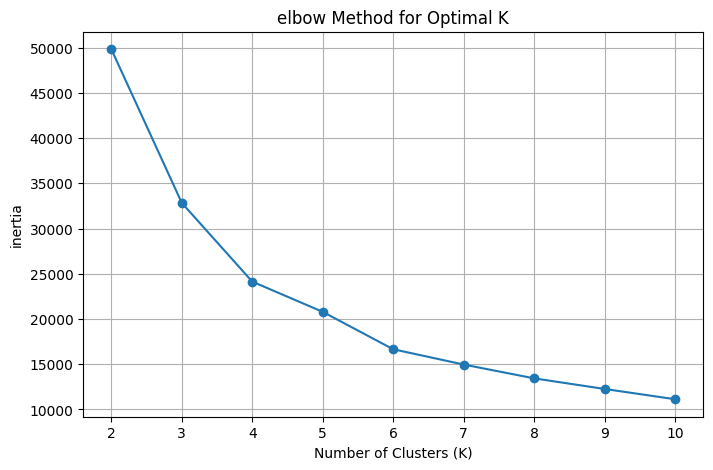

In [43]:
# plot elbow graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("inertia")
plt.title("elbow Method for Optimal K")
plt.grid(True)
plt.show()


In [44]:
# silhouette analysis to find optimal K
from sklearn.metrics import silhouette_score
silhouette_scores = [] # create silhouette scores list
K = range(2, 11) # set range of K values to try
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(score)


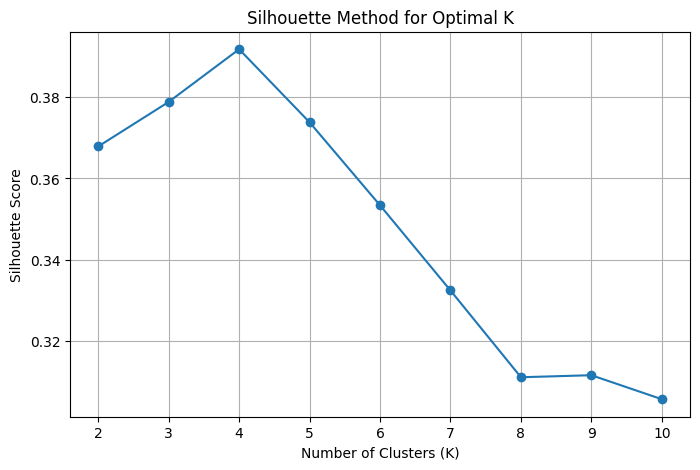

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal K")
plt.grid(True)
plt.show()


In [46]:
# fit KMeans with chosen K
k_chosen = 4
kmeans = KMeans(n_clusters = k_chosen, random_state=42)
kmeans.fit(X_scaled)
Labels = kmeans.labels_

In [52]:
# attach cluster labels to original dataframe
cleanF18['Cluster'] = Labels

# group by cluster and calculate mean values for each cluster
cluster_summary = cleanF18.groupby('Cluster').mean(numeric_only=True)
cluster_summary

,Age,Overall,Value,Wage
Cluster,,,,
0,20.593533,60.884671,5.501826e+05,3046.668412
1,25.669034,76.720644,1.001581e+07,39816.761364
2,26.757353,85.889706,4.559559e+07,184742.647059
3,28.107214,68.197388,1.414245e+06,8012.562189


Cluster 0 → “Low-Tier Youth Players” (Young, Low OVR, Very Low Value)
Characteristics:

Youngest players (age ~20.6)

Low overall rating (~60.9)

Very cheap value (~€0.5M)

Very low wages (~€3K)

Interpretation:

These are youth squad, fringe players, or low-potential prospects.
They’re too cheap to be “budget gems” and too low-rated to be meaningful in value-for-money analysis.

Suitable label: Developing / Replacement-Level Youth

Cluster 1 → “Prime Star Players” (Mid-20s, High OVR, Expensive)
Characteristics:

Age ~25.7 (prime years)

High overall (~76.7)

Highest market value (~€10M)

Highest wages (~€40K)

Interpretation:

These are your prime performers — good starters, high market value, strong contributors.

Suitable label: Established Prime Players

Not overpriced — just naturally expensive.

Cluster 2: “Elite Bargains / High-Value Performers” (High OVR, Low Wage)
Characteristics:

Age ~26.7 (also prime)

Highest Overall (~85.9)

Lower value (~€4.5M) compared to cluster 1

Low wage (~€18K)

Interpretation:

This is your best cluster:

They have the highest performance rating (OVR 85.9)

Their value is less than half of Cluster 1 (€4.5M vs €10M)

Their wage is also much lower

These are underpriced stars → the true “value for money” players.

 Perfect label: Elite Budget Gems / Undervalued Stars



Cluster 3: “Affordable Veterans” (Older, Mid OVR, Low Value)
Characteristics:

Oldest players (~28 years)

Lower OVR (~68.2)

Still very cheap (~€1.4M)

Low/mid wage (~€8K)

Interpretation:

These players are:

Slightly older

Lower performance

Much cheaper

They’re classic short-term squad depth players — not young prospects, not stars.

 Suitable label:
Affordable Experienced Players
or
Aging Role Players

 Summary of Final Cluster Types:

Cluster	Type
0	Developing Youth / Low-Potential Prospects
1	Established Prime Players
2	Elite Budget Gems / Undervalued Stars
3	Affordable Experienced Players
 Which group is best value-for-money?

 Cluster 2 — Elite Budget Gems

Highest OVR

Low wage

Moderate value

Best OVR per euro

This is likely your “undervalued cluster.”

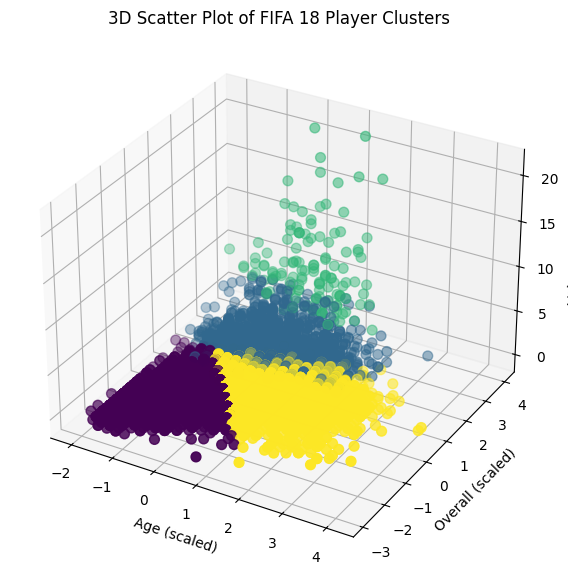

In [ ]:
# plot 3D plot of clusters
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
    c=Labels, cmap='viridis', s=50
)
ax.set_xlabel('Age (scaled)')
ax.set_ylabel('Overall (scaled)')
ax.set_zlabel('Value (scaled)')
ax.set_title('3D Scatter Plot of FIFA 18 Player Clusters')
plt.show()

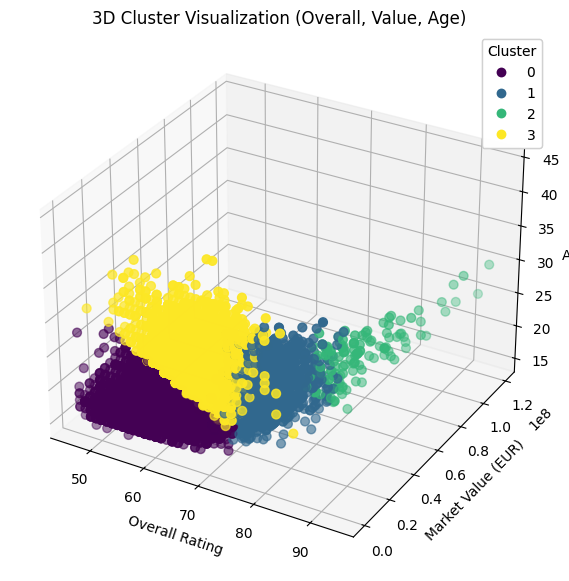

In [54]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    cleanF18['Overall'], 
    cleanF18['Value'], 
    cleanF18['Age'],
    c=cleanF18['Cluster'],    # color by cluster label
    cmap='viridis',           # color map
    s=40                      # point size
)

ax.set_xlabel('Overall Rating')
ax.set_ylabel('Market Value (EUR)')
ax.set_zlabel('Age')
ax.set_title('3D Cluster Visualization (Overall, Value, Age)')

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.show()
